This project focuses on building Machine Learning classification models to predict whether a breast tumor is malignant(M) or bening (B) using medical measurements.


The goal o this project is :
1. To explore and understand the dataset
2. To prepare the data fro machine learning
3. To train different classification models
4. To evaluate and compare their performance


Theory of Libraries 

Pandas : Used for handling data

NumPy : Used for mathematical operations

Matplotlib / Seaborn : Used for data  visualization

Scikit-Learn : used for machine learning models


In [257]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics ,tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  accuracy_score, confusion_matrix, precision_score, f1_score, classification_report, recall_score, mean_squared_error, r2_score 
from sklearn.preprocessing import MinMaxScaler

Loading the Dataset

In [258]:
data = pd.read_csv(r"C:\Users\user\Downloads\archive (6)\breast-cancer.csv")

Understanding the Data

data.info()

Shows : Number of rows , Number of columns, Data types and missing values

data.shape 

returns: Numbers of rows, Number of columns 

data.describe()

Shows statistical summary of each column: Mean , Standard deviation, Minimum, Maximum, Percentiles.
    

In [259]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [260]:
data.shape

(569, 32)

Theory

Missing values can damage model performance, This command checks if any column contains empty values

In [261]:
missing_values = data.isnull().sum()
missing_values

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [262]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Counts how many patients are:

Bening (B)

Malignant (M)

This hepls us understand if the dataset is balanced

In [263]:
Catigorical_counts = data["diagnosis"].value_counts()
Catigorical_counts

diagnosis
B    357
M    212
Name: count, dtype: int64

Theory 
Feature Engineering means creating new  variables from existing ones

Why;

Because new features may help the model understand patterns better.
    

In [264]:
data["compactness_index"] = (data["perimeter_mean"] ** 2) / data["area_mean"]
data["radius_diff"] = data["radius_worst"] - data["area_mean"]

Τhis command:
Groups the bataset by column "diagnosis"

Separates the data into two groups:

1)Bening (B)

2)Malignant (M)

Calculates the mean of selected numerical features for each group

In [265]:
Catigorical_means = data.groupby("diagnosis")[["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean","radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst", "compactness_worst" , "symmetry_worst", "fractal_dimension_worst", "compactness_index", "radius_diff"]].mean()


In [266]:
Catigorical_means.round(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,symmetry_worst,fractal_dimension_worst,compactness_index,radius_diff
diagnosis,,,,,,,,,,,,,,,,,,,
B,12.15,17.91,78.08,462.79,0.09,0.08,0.05,0.03,0.17,13.38,23.52,87.01,558.90,0.12,0.18,0.27,0.08,13.46,-449.41
M,17.46,21.60,115.37,978.38,0.10,0.15,0.16,0.09,0.19,21.13,29.32,141.37,1422.29,0.14,0.37,0.32,0.09,14.06,-957.24


Histograms show the distribution of values 

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>,
        <Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>],
       [<Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 's

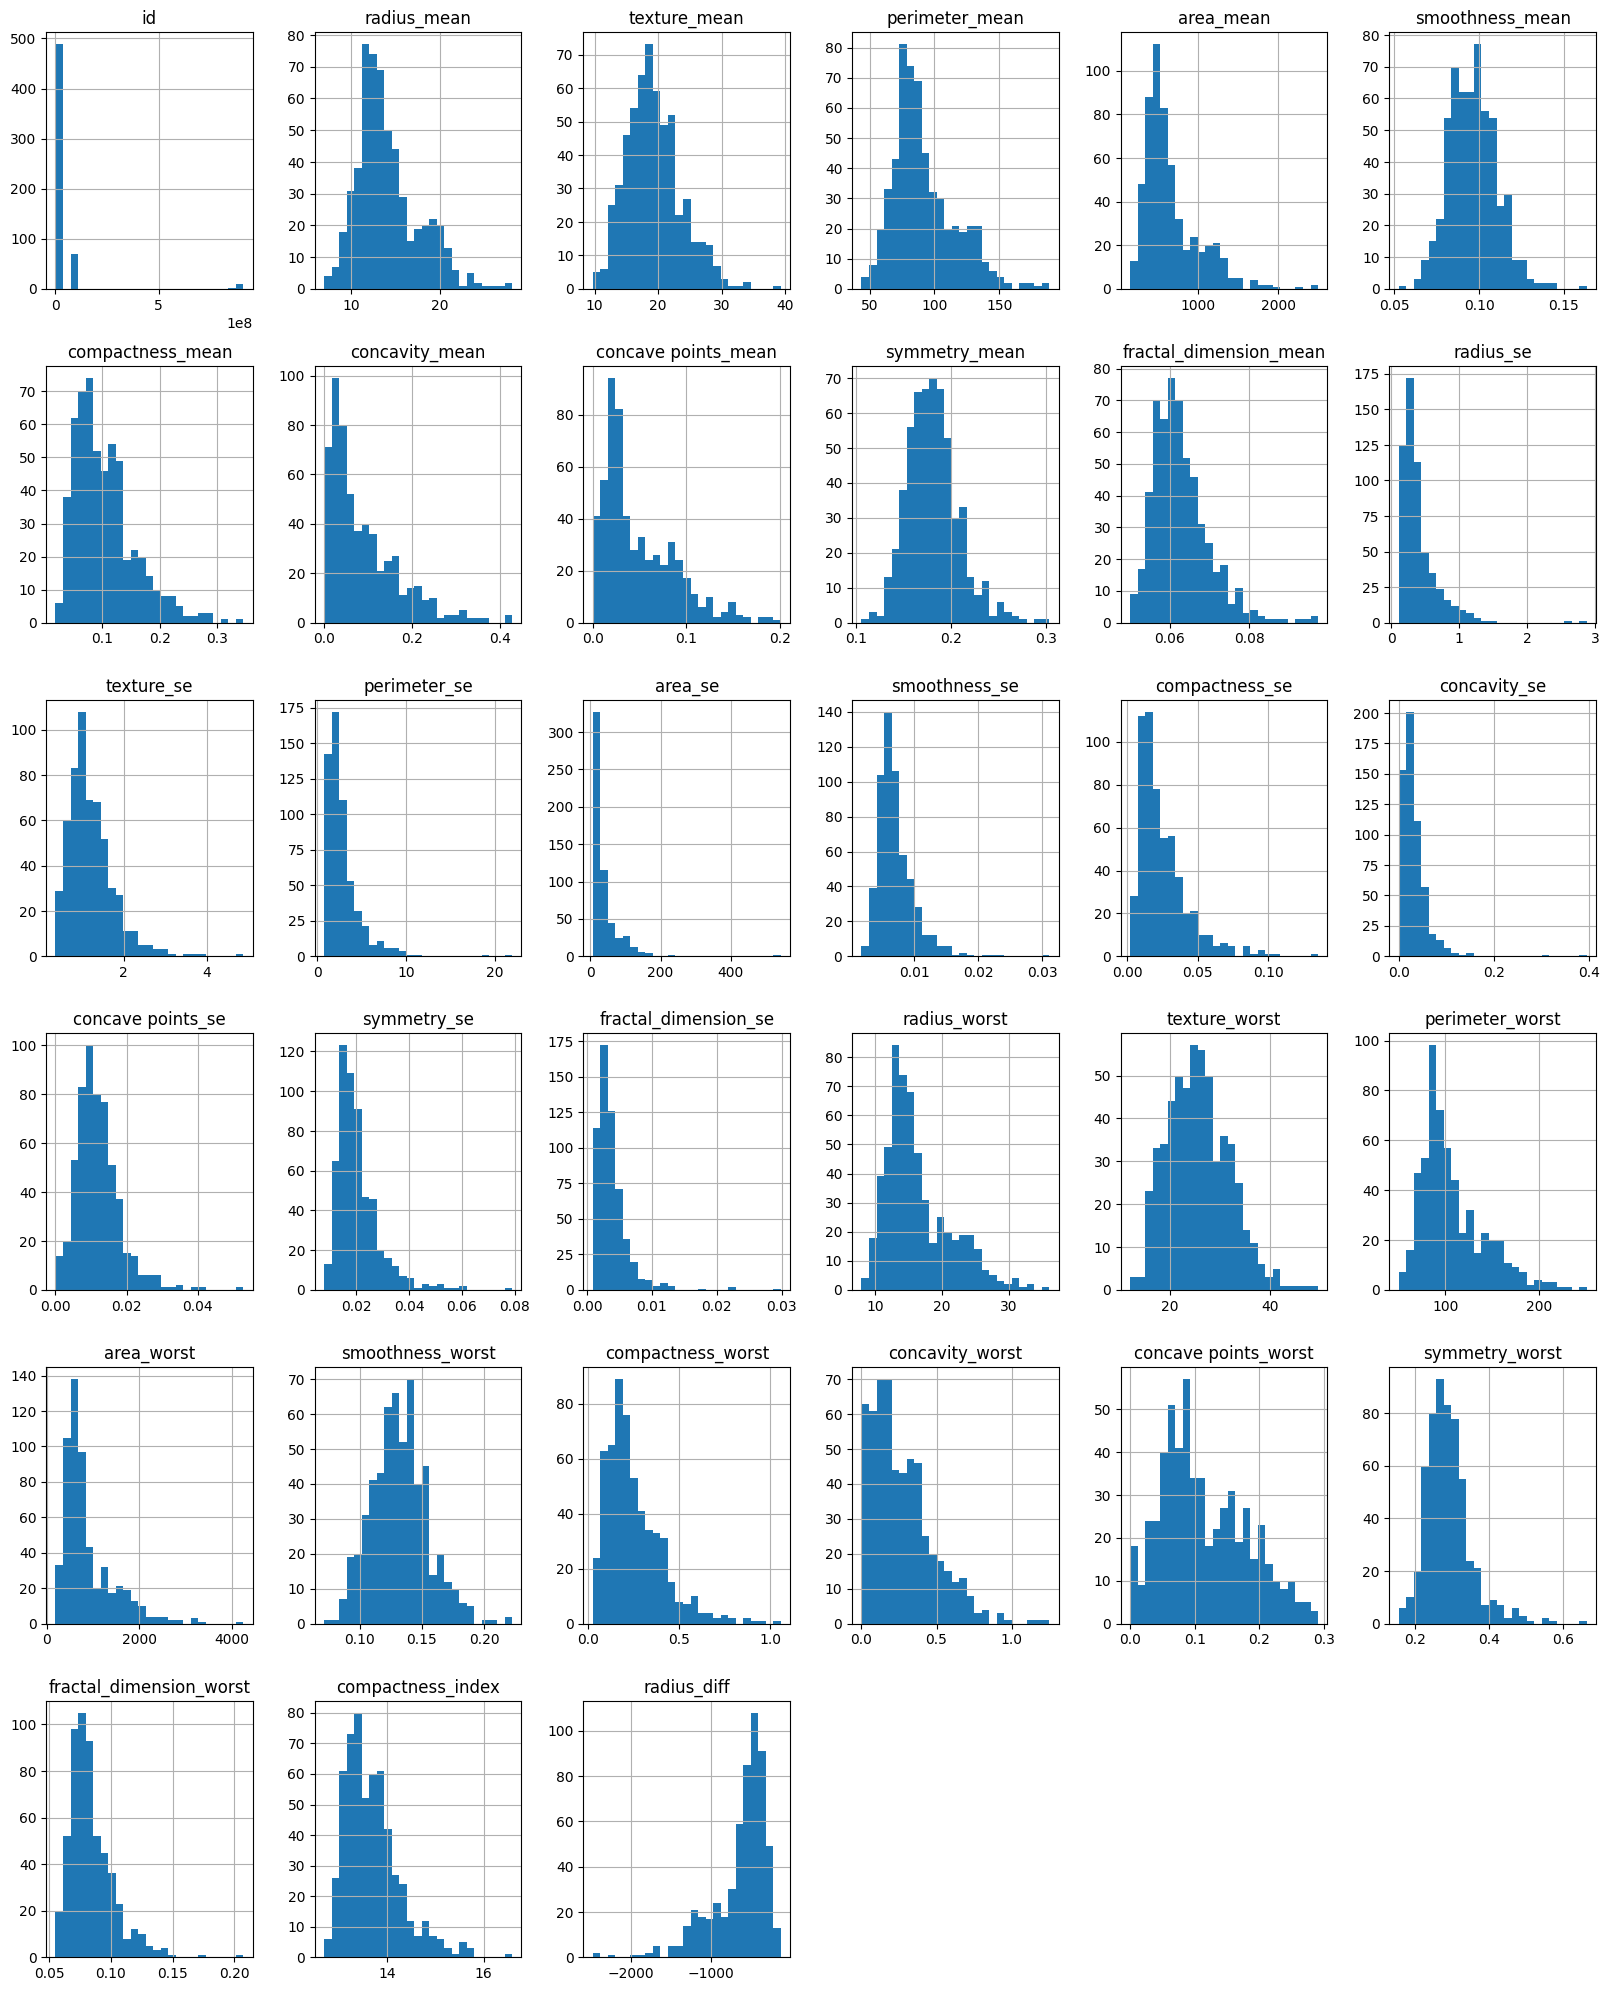

In [267]:
data.hist(bins=25, figsize=(20, 25))

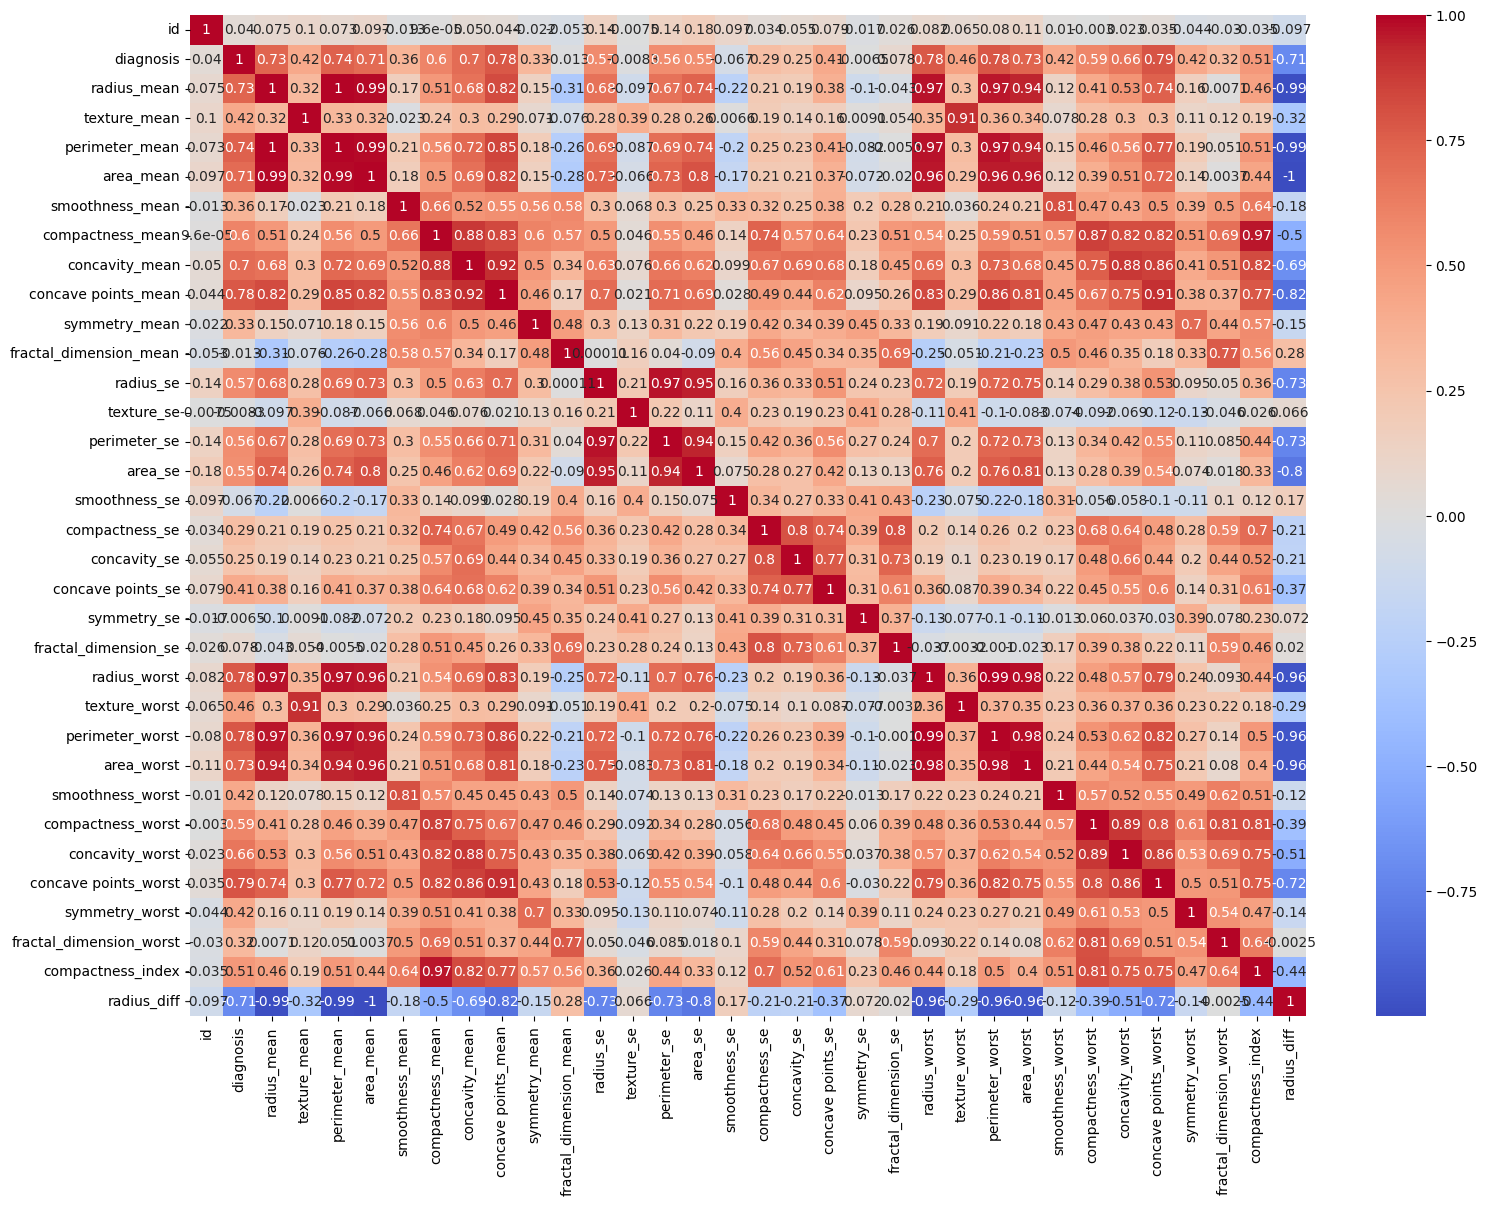

In [280]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(18, 13))
sns.heatmap(corr, annot = True, cmap="coolwarm")
plt.show()

This boxplot shows the distribution (mean, max, min) of concave points_worst for

B(Bening)

M(Malignant)



Text(0, 0.5, 'concave points_worst')

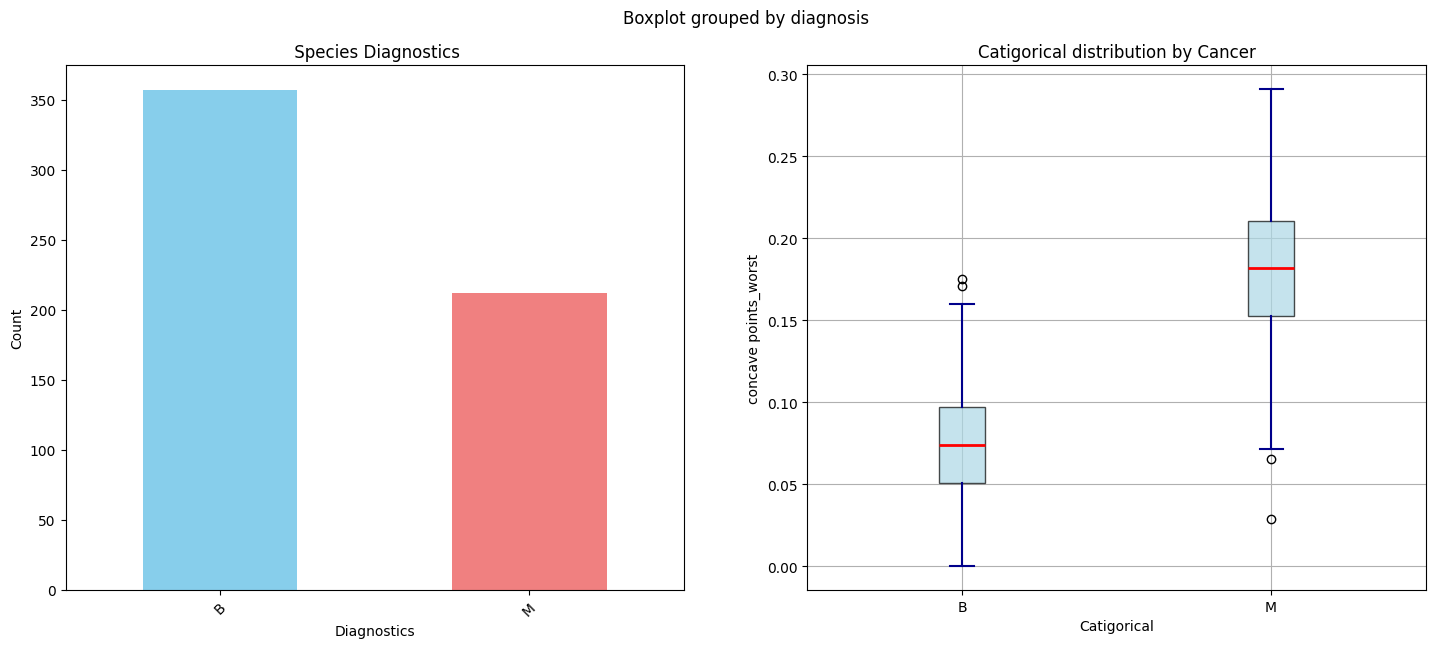

In [268]:
fig, axes = plt.subplots(1, 2, figsize = (17, 7))
fig.suptitle("Diagnosis Cancer", fontsize=16, fontweight="bold")
Catigorical_counts.plot(
    kind="bar", ax = axes[0], color = ["skyblue", "lightcoral"]
)
axes[0].set_title(" Species Diagnostics")
axes[0].set_xlabel("Diagnostics")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

data.boxplot(
    column = "concave points_worst",
    by = "diagnosis",
    ax = axes[1],
    patch_artist = True,
    boxprops = dict(facecolor="lightblue", alpha=0.7),
    medianprops = dict(color ="red", linewidth = 2),
    whiskerprops = dict(color = "darkblue", linewidth = 1.5),
    capprops = dict(color = "darkblue", linewidth = 1.5),
  
)

axes[1].set_title("Catigorical distribution by Cancer")
axes[1].set_xlabel("Catigorical")
axes[1].set_ylabel("concave points_worst")

Machine learning models cannot understand text.

So we convert:

Malignant (1)
Benign (0)

This is called Label Encoding

Scaling transforms features to a similar range (0-1).

Why important;

Some algorithms (like KNN) are sensitive to scale.



In [269]:
data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

X = data.drop(columns = ["id", "diagnosis"])

y = data["diagnosis"]

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


We split the data into : 

Training set (70%)

Test set (30%)

Why ;
The model learns from training data, then we test it on unseen data


In [270]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

Decision Tree
A Decision Tree splits the data using questions like:
is radius >15;

is concavity < 0.1;

It builds a tree structure of decisions 

In [271]:
dtree = tree.DecisionTreeClassifier(criterion = "entropy")
dtree.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [272]:
y_pred = dtree.predict(X_test)

Confusion Matrix 
Shows:
True positives   True Negatices 

False Positives   False negatives

Precision = All of predictes malignant cases, how many were correct;

Important when False Positives are costly

Recall

of all real malignant, how many did we detect;
Human example

If 100 people have cancer,

and you detect 90,

Recall = 90%

F1 = Balance between Precision and Recall
Used when both False Positives and False Negatives matter.

In [273]:

print(precision_score(y_test, y_pred))
x2 = precision_score(y_test, y_pred)

0.9076923076923077


In [274]:
print(confusion_matrix(y_test, y_pred))


[[101   6]
 [  5  59]]


In [275]:
print(recall_score(y_test, y_pred))
y2 = recall_score(y_test, y_pred)

0.921875


In [210]:
print(f1_score(y_test, y_pred))
z2 = f1_score(y_test, y_pred)

0.9147286821705426


In [ ]:
K-Nearest Neighbors
KNN looks at the 10 closest patients 

If most neighbors are malignant, the new patient is predicted malignant

In [ ]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.30, random_state=21)

In [ ]:
knnClass = KNeighborsClassifier(n_neighbors = 10)

In [ ]:
knnClass.fit(X_train1, y_train1)

In [ ]:
y_pred1 = knnClass.predict(X_test)

In [ ]:
print(precision_score(y_test1, y_pred1))
print(confusion_matrix(y_test1, y_pred1))
print(f1_score(y_test1, y_pred1))
print(recall_score(y_test1, y_pred1))

xx=precision_score(y_test1, y_pred1)
yy=recall_score(y_test1, y_pred1)
zz=f1_score(y_test1, y_pred1)

Random Forest

Random Forest builds many decision trees.
    
Final prediction = majority vote of all trees

why better ;

It reduces overfitting 

Human Example

Instead of asking one doctor , 

you ask 20 doctors and take the majority opinion



In [216]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.30, random_state=21)

In [217]:
rf_model = RandomForestClassifier(n_estimators = 20, random_state = 30)

In [218]:
rf_model.fit(X_train2, y_train2)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [219]:
y_pred2 = rf_model.predict(X_test2)

In [220]:
print(precision_score(y_test2, y_pred2))
print(confusion_matrix(y_test2, y_pred2))
print(f1_score(y_test2, y_pred2))
print(recall_score(y_test2, y_pred2))
xx1 = precision_score(y_test2, y_pred2)
yy1 = recall_score(y_test2, y_pred2)
zz1 = f1_score(y_test2, y_pred2)

0.9830508474576272
[[106   1]
 [  6  58]]
0.943089430894309
0.90625


In [221]:
Evalutation = pd.DataFrame({
    "Models": ["DecisionTree", "KNeighbors" ,"RandomForest"],
    "Precision" : [x2,xx, xx1],
    "recall_score": [y2, yy, yy1],
    "f1_score" : [z2, zz, zz1]

})
Evalutation

,Models,Precision,recall_score,f1_score
0,DecisionTree,0.907692,0.921875,0.914729
1,KNeighbors,0.919355,0.890625,0.904762
2,RandomForest,0.983051,0.906250,0.943089
